# 🚀 BHARATH BUILDS
## 21 DAYS TO ML ENGINEER — DAY 5

# Logistic Regression + Decision Threshold

---

## 🎯 Objective

Build a binary classification model using Logistic Regression and understand how predicted probabilities are converted into final class predictions using a decision threshold.

---

## 📚 Topics Covered

### 1. Classification
- Classification vs Regression
- Binary Classification

### 2. Logistic Regression
- Linear Score
- Sigmoid Function
- Probability Output

### 3. Decision Threshold
- Default Threshold — 0.5
- Lower Threshold — 0.3
- Higher Threshold — 0.7
- Threshold Trade-offs

### 4. Model Training
- Load Dataset
- Feature and Target Separation
- Train-Test Split
- Feature Scaling
- Logistic Regression Pipeline
- Model Training

### 5. Model Prediction
- `predict()`
- `predict_proba()`
- Class 1 Probability
- Probability-to-Class Conversion

### 6. Model Evaluation
- Accuracy
- Precision
- Recall
- Confusion Matrix
- True Positive (TP)
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)

### 7. Threshold Experiment
- Threshold = 0.3
- Threshold = 0.5
- Threshold = 0.7
- Precision and Recall Comparison
- FP and FN Analysis

---

## 🧠 Core ML Flow

Features
↓
Linear Score
↓
Sigmoid Function
↓
Probability
↓
Decision Threshold
↓
Class Prediction
↓
Confusion Matrix
↓
Precision / Recall

---

## 📊 Dataset

**Breast Cancer Wisconsin Dataset**

Binary Classification:

- Class 0
- Class 1

---

## 🔬 Practical Experiment

Compare the same Logistic Regression model using different decision thresholds:

| Threshold | Purpose |
|-----------|---------|
| 0.3 | Lower threshold |
| 0.5 | Default threshold |
| 0.7 | Higher threshold |

Analyze how changing the threshold affects:

- Predictions
- True Positives
- True Negatives
- False Positives
- False Negatives
- Precision
- Recall

---

## 🎓 Learning Outcome

By the end of this notebook, we will understand:

**How Logistic Regression produces probabilities and how a decision threshold converts those probabilities into classification decisions.**

step 1: import lib


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss
    )


step 2 load dataset

In [4]:
data=load_breast_cancer()

step3: sepearate features and target

In [5]:
X=data.data
y=data.target

step4: minimal dataset check

In [6]:
print("feature shape:",X.shape)
print("target shape:",y.shape)
print("classes:",data.target_names)

feature shape: (569, 30)
target shape: (569,)
classes: ['malignant' 'benign']


step 5: train test split

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)

step 6: feature scaling

In [10]:
scaler=StandardScaler()


step 7 : build pipeline

In [11]:
model=Pipeline([("scaler",StandardScaler()),("model",LogisticRegression(max_iter=1000))])

step8: model training

In [12]:
model.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

step 9 : make prediction

In [13]:
y_pred=model.predict(X_test)
print(y_pred[:20])

[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


step 10 : baseline evaluation

In [14]:
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))
print("Recall",recall_score(y_test,y_pred))

Accuracy 0.9824561403508771
Precision 0.9861111111111112
Recall 0.9861111111111112


step 11: get probability

In [18]:
y_proba=model.predict_proba(X_test)
print(y_proba[:5])

[[9.99999941e-01 5.88824186e-08]
 [1.13351672e-05 9.99988665e-01]
 [9.93589175e-01 6.41082462e-03]
 [4.66491463e-01 5.33508537e-01]
 [9.99999999e-01 6.52500097e-10]]


step 12: extract class1 probabillty

In [19]:
positive_proba=y_proba[:,1]
print(positive_proba[:5])

[5.88824186e-08 9.99988665e-01 6.41082462e-03 5.33508537e-01
 6.52500097e-10]


step 13: threshold=0.5

In [21]:
threshold=0.5
y_pred_05=(positive_proba>=threshold).astype(int)
print(y_pred_05[:5])

[0 1 0 1 0]


step 14: threshold = 0.3

In [22]:
threshold=0.3
y_pred_03=(positive_proba>=threshold).astype(int)

print("Accuracy",accuracy_score(y_test,y_pred_03))
print("Precision",precision_score(y_test,y_pred_03))
print("Recall",recall_score(y_test,y_pred_03))


Accuracy 0.9824561403508771
Precision 0.972972972972973
Recall 1.0


step 15 threshold=0.7

In [23]:
threshold=0.7
y_pred_07=(positive_proba>=threshold).astype(int)

print("Accuracy",accuracy_score(y_test,y_pred_07))
print("Precision",precision_score(y_test,y_pred_07))
print("Recall",recall_score(y_test,y_pred_07))



Accuracy 0.9473684210526315
Precision 0.9852941176470589
Recall 0.9305555555555556


step 16: confusion matrix

In [24]:
cm_05=confusion_matrix(y_test,y_pred_05)
print(cm_05)

[[41  1]
 [ 1 71]]


step17: visualise confusion matrix

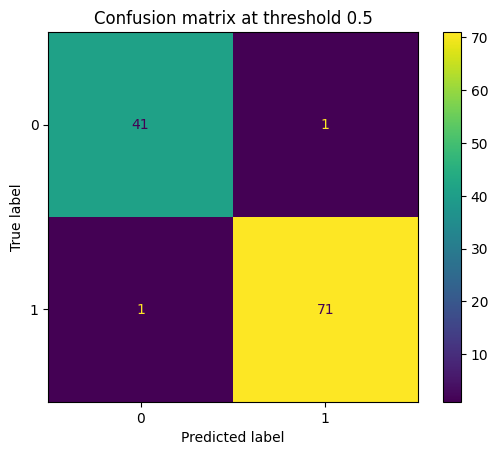

In [26]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_05)

plt.title("Confusion matrix at threshold 0.5")
plt.show()


step 18: comp[are all the thresholds (*0.3, 0.5,0.7)

In [28]:
thresholds=[0.3,0.5,0.7]

results=[]

for threshold in thresholds:
  predictions=(positive_proba>=threshold).astype(int)

  results.append({
      "threshold":threshold,
      "accuracy":accuracy_score(y_test,predictions),
      "precision":precision_score(y_test,predictions),
      "recall":recall_score(y_test,predictions),
  })

  results_df=pd.DataFrame(results)
  print(results_df)


   threshold  accuracy  precision  recall
0        0.3  0.982456   0.972973     1.0
   threshold  accuracy  precision    recall
0        0.3  0.982456   0.972973  1.000000
1        0.5  0.982456   0.986111  0.986111
   threshold  accuracy  precision    recall
0        0.3  0.982456   0.972973  1.000000
1        0.5  0.982456   0.986111  0.986111
2        0.7  0.947368   0.985294  0.930556


step 19: error analysis

In [29]:
comparision=pd.DataFrame({"actual":y_test,"probability":positive_proba,"prediction_05":y_pred_05,"prediction_03":y_pred_03,"prediction_07":y_pred_07})
print(comparision.head(10))

   actual   probability  prediction_05  prediction_03  prediction_07
0       0  5.888242e-08              0              0              0
1       1  9.999887e-01              1              1              1
2       0  6.410825e-03              0              0              0
3       1  5.335085e-01              1              1              0
4       0  6.525001e-10              0              0              0
5       1  9.921604e-01              1              1              1
6       1  9.999828e-01              1              1              1
7       0  5.635275e-07              0              0              0
8       0  5.431637e-05              0              0              0
9       0  8.041849e-11              0              0              0


In [30]:
# false positive

fp=comparision[(comparision["actual"]==0) & (comparision["prediction_05"]==1)]
print(fp)

    actual  probability  prediction_05  prediction_03  prediction_07
53       0     0.908728              1              1              1


In [32]:
# false negative

fn=comparision[(comparision["actual"]==1) & (comparision["prediction_05"]==0)]
print(fn)

    actual  probability  prediction_05  prediction_03  prediction_07
16       1     0.365862              0              1              0


In [33]:
threshold_results=[]

for threshold in [0.3,0.5,0.7]:
  predictions=(positive_proba>=threshold).astype(int)

  cm=confusion_matrix(y_test,predictions)
  tn,fp,fn,tp=cm.ravel()

  threshold_results.append({
      "threshold":threshold,
      "true_negatives":tn,
      "false_positives":fp,
      "false_negatives":fn,
      "true_positives":tp,
      "accuracy":accuracy_score(y_test,predictions),
      "precision":precision_score(y_test,predictions),
      "recall":recall_score(y_test,predictions),
  })

  threshold_results_df=pd.DataFrame(threshold_results)
  print(threshold_results_df)
#


   threshold  true_negatives  false_positives  false_negatives  \
0        0.3              40                2                0   

   true_positives  accuracy  precision  recall  
0              72  0.982456   0.972973     1.0  
   threshold  true_negatives  false_positives  false_negatives  \
0        0.3              40                2                0   
1        0.5              41                1                1   

   true_positives  accuracy  precision    recall  
0              72  0.982456   0.972973  1.000000  
1              71  0.982456   0.986111  0.986111  
   threshold  true_negatives  false_positives  false_negatives  \
0        0.3              40                2                0   
1        0.5              41                1                1   
2        0.7              41                1                5   

   true_positives  accuracy  precision    recall  
0              72  0.982456   0.972973  1.000000  
1              71  0.982456   0.986111  0.986111  

#  FINAL OBSERVATION — THRESHOLD EXPERIMENT

We tested the same Logistic Regression model with three different decision thresholds:

- 0.3
- 0.5
- 0.7

The model and test data remained the same. Only the decision threshold changed.

---

## 1️ Threshold = 0.3

- True Negatives = 40
- False Positives = 2
- False Negatives = 0
- True Positives = 72
- Accuracy = 98.25%
- Precision = 97.30%
- Recall = 100%

With a lower threshold, the model becomes less strict when predicting Class 1.

The important observation:

- All 72 positive cases were correctly identified.
- False Negatives = 0
- Only 2 negative cases were incorrectly classified as positive.

### Key Takeaway

**Lower Threshold → Higher Recall**

**0.3 → Maximum Recall**

---

## 2️ Threshold = 0.5

- True Negatives = 41
- False Positives = 1
- False Negatives = 1
- True Positives = 71
- Accuracy = 98.25%
- Precision = 98.61%
- Recall = 98.61%

This is the default threshold commonly used by Logistic Regression.

Compared with 0.3:

- False Positives decreased from 2 → 1
- False Negatives increased from 0 → 1
- Precision increased
- Recall slightly decreased
- Accuracy remained the same at 98.25%

### Key Takeaway

**0.5 → Balanced Performance**

---

## 3️ Threshold = 0.7

- True Negatives = 41
- False Positives = 1
- False Negatives = 5
- True Positives = 67
- Accuracy = 94.74%
- Precision = 98.53%
- Recall = 93.06%

With a higher threshold, the model becomes more strict when predicting Class 1.

The important observation:

- False Positives remained low.
- False Negatives increased from 1 → 5.
- Recall decreased from 98.61% → 93.06%.
- Accuracy decreased from 98.25% → 94.74%.

### Key Takeaway

**Higher Threshold → More Missed Positives**

---

#  THRESHOLD COMPARISON

| Threshold | TP | TN | FP | FN | Accuracy | Precision | Recall |
|-----------|---:|---:|---:|---:|---------:|----------:|-------:|
| 0.3 | 72 | 40 | 2 | 0 | 98.25% | 97.30% | 100.00% |
| 0.5 | 71 | 41 | 1 | 1 | 98.25% | 98.61% | 98.61% |
| 0.7 | 67 | 41 | 1 | 5 | 94.74% | 98.53% | 93.06% |

---

# 🔍 OVERALL OBSERVATION

Changing the threshold does not retrain the model.

The model remains the same.

The probability predictions remain the same.

Only the decision rule changes.

```text
Same Model
    ↓
Same Probabilities
    ↓
Different Threshold
    ↓
Different Predictions
    ↓
Different FP / FN
    ↓
Different Precision / Recall

#  FINAL KEY TAKEAWAY — DAY 5

##  Theoretical Takeaway

- **Classification** predicts a category or class instead of a continuous numerical value.
- **Logistic Regression** converts the model's linear output into a probability using the **Sigmoid Function**.
- `predict_proba()` gives the probability of each class, while `predict()` converts that probability into a final class using a **decision threshold**.
- The **decision threshold** controls how easily the model predicts the positive class.
- A **lower threshold** generally increases Recall and reduces False Negatives, but may increase False Positives.
- A **higher threshold** generally increases the strictness of positive predictions, which can increase False Negatives and reduce Recall.
- **Log Loss** evaluates how close predicted probabilities are to the actual class.
- A **Confusion Matrix** helps understand the types of mistakes made by the classifier:
  - **TP:** Actual 1 → Predicted 1
  - **TN:** Actual 0 → Predicted 0
  - **FP:** Actual 0 → Predicted 1
  - **FN:** Actual 1 → Predicted 0
- **Accuracy alone is not enough** to evaluate a classification model. Precision, Recall, and the actual error types must also be considered.

---

##  Practical Takeaway

Using the **Breast Cancer dataset**, we:

1. Loaded and prepared the dataset.
2. Split the data into training and testing sets.
3. Applied feature scaling.
4. Built a Logistic Regression model using a pipeline.
5. Generated class predictions using `predict()`.
6. Generated probability predictions using `predict_proba()`.
7. Tested different decision thresholds: **0.3, 0.5, and 0.7**.
8. Compared the resulting confusion matrices and evaluation metrics.
9. Performed error analysis using **False Positives and False Negatives**.

### Threshold Results

| Threshold | Accuracy | Precision | Recall | FP | FN |
|---|---:|---:|---:|---:|---:|
| **0.3** | 98.25% | 97.30% | **100%** | 2 | **0** |
| **0.5** | **98.25%** | **98.61%** | **98.61%** | **1** | **1** |
| **0.7** | 94.74% | 98.53% | 93.06% | 1 | 5 |

###  What the Experiment Proved

- At **0.3**, the model caught every positive case → **Recall = 100%**, but produced more False Positives.
- At **0.5**, the model achieved a strong balance between Precision and Recall.
- At **0.7**, the stricter threshold reduced Recall and increased False Negatives.
- **0.3 and 0.5 had the same accuracy (98.25%)**, but their error patterns were different.

This proves that **accuracy alone cannot determine the best threshold**.

---

##  ML Engineering Takeaway

The important lesson is not simply how to train Logistic Regression.

The real engineering workflow is:

**Train Model → Generate Probabilities → Choose Threshold → Evaluate Errors → Analyze Business Cost → Select Threshold**

The model produces the **probability**.

The **threshold converts probability into a class**.

The best threshold depends on the real-world cost of **False Positives vs False Negatives**.

> **Model training is only one part of a classification system.  
> Threshold selection and error analysis are also important engineering decisions.**

---

##  Day 5 summarry

**Logistic Regression gives us probabilities, and the decision threshold determines how those probabilities become real-world decisions.**